<a href="https://colab.research.google.com/github/sri-wahyuni10/Inter-flyrank/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

**Three reason codes, in priority order:**

1. `NO_GA4_TRACKING` -> `CONNECT_GA4_TRACKING`. Content with no GA4 connection at all
   (`has_ga4_data=0`) gets top priority not because it's underperforming, but because we
   **can't reliably measure it** -- fixing tracking is a prerequisite for trusting any other
   recommendation about that content. This is a data-quality action, not a content-quality one.
2. `HIGH_IMP_LOW_CTR` -> `OPTIMIZE_TITLE_META`. Driven by the Week-5/6 model: the probability
   that a piece of content is underperforming CTR relative to its impression-bucket peers,
   evaluated honestly on a client-grouped holdout (see Week 6). Ranked by
   `model_probability x total_impressions`, so we lead with content where both the confidence
   and the potential impact are highest.
3. `STRIKING_DISTANCE` -> `IMPROVE_RELEVANCE_LINKING`. Position 11-20, the zone FlyRank's own
   published research (Finding #3) calls the highest-ROI optimization tier. **This reason code
   is informed by that external, published finding -- it has not been independently validated
   against this portfolio's own outcomes**, so it's ranked by raw impressions rather than by a
   model score, and flagged as directional, not confirmed.

Archetypes below are built from OUR OWN bucket features (impression bucket x position tier x
GA4-connection status) -- not the paper's k-means clusters, which the paper itself cautions are
"not production-ready personas."

In [1]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one -- typing sentences here breaks Run All.

import gc, os, json
import numpy as np
import pandas as pd
import duckdb
from google.colab import userdata
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# --- Rebuild the same feature table as w05/w06 ---
con = duckdb.connect()
hf_token = userdata.get("HF_TOKEN")
if not hf_token:
    raise ValueError("Make sure you have set the Secrets 'HF_TOKEN' in Google Colab!")
con.execute("INSTALL httpfs;")
con.execute("LOAD httpfs;")
con.execute("SET max_memory='4GB';")
con.execute("SET threads=2;")
con.execute(f"""
    CREATE SECRET http_auth (
        TYPE http,
        EXTRA_HTTP_HEADERS MAP {{'Authorization': 'Bearer {hf_token}'}}
    );
""")

dataset_url = "hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/**/*.parquet"

q_features = f"""
SELECT
    content_hash_id,
    ANY_VALUE(client_hash_id)                as client_hash_id,
    SUM(gsc_impressions)                     as total_impressions,
    SUM(gsc_clicks)                          as total_clicks,
    AVG(gsc_avg_position)                    as avg_position,
    COUNT(*)                                 as n_days,
    SUM(ga4_pageviews)                       as ga4_pageviews,
    SUM(ga4_sessions)                        as ga4_sessions,
    SUM(ga4_users)                           as ga4_users,
    SUM(ga4_engaged_sessions)                as ga4_engaged_sessions,
    SUM(ga4_total_engagement_sec)            as ga4_total_engagement_sec,
    SUM(sessions_organic)                    as sessions_organic,
    SUM(sessions_direct)                     as sessions_direct,
    SUM(sessions_referral)                   as sessions_referral,
    SUM(sessions_social)                     as sessions_social,
    SUM(sessions_paid)                       as sessions_paid,
    SUM(sessions_ai)                         as sessions_ai,
    SUM(ai_chatgpt)                          as ai_chatgpt,
    SUM(ai_perplexity)                       as ai_perplexity,
    SUM(ai_gemini)                           as ai_gemini,
    SUM(ai_copilot)                          as ai_copilot,
    SUM(ai_claude)                           as ai_claude,
    SUM(ai_meta)                             as ai_meta,
    SUM(ai_other)                            as ai_other,
    SUM(scroll_events)                       as scroll_events
FROM read_parquet('{dataset_url}')
WHERE gsc_data_available = true
GROUP BY 1
"""
df = con.execute(q_features).df()
df["ctr"] = np.where(df["total_impressions"] > 0, df["total_clicks"] / df["total_impressions"], 0)
df = df[df["total_impressions"] >= 10].reset_index(drop=True)

imp_bins = [0, 10, 100, 1000, np.inf]
imp_labels = ["1.Low", "2.Medium", "3.High", "4.Critical"]
df["imp_bucket"] = pd.cut(df["total_impressions"], bins=imp_bins, labels=imp_labels, right=False)

ga4_session_ai_cols = [
    "ga4_pageviews", "ga4_sessions", "ga4_users", "ga4_engaged_sessions", "ga4_total_engagement_sec",
    "sessions_organic", "sessions_direct", "sessions_referral", "sessions_social", "sessions_paid", "sessions_ai",
    "ai_chatgpt", "ai_perplexity", "ai_gemini", "ai_copilot", "ai_claude", "ai_meta", "ai_other",
    "scroll_events",
]
df[ga4_session_ai_cols] = df[ga4_session_ai_cols].fillna(0)
df["avg_position"] = df["avg_position"].fillna(df["avg_position"].max())

q_ga4_flag = f"""
SELECT content_hash_id, MAX(CASE WHEN ga4_data_available THEN 1 ELSE 0 END) as has_ga4_data
FROM read_parquet('{dataset_url}') GROUP BY 1
"""
df = df.merge(con.execute(q_ga4_flag).df(), on="content_hash_id", how="left")

feature_cols = [
    "avg_position", "n_days", "total_impressions", "has_ga4_data",
    "ga4_pageviews", "ga4_sessions", "ga4_users", "ga4_engaged_sessions", "ga4_total_engagement_sec",
    "sessions_organic", "sessions_direct", "sessions_referral", "sessions_social", "sessions_paid", "sessions_ai",
    "ai_chatgpt", "ai_perplexity", "ai_gemini", "ai_copilot", "ai_claude", "ai_meta", "ai_other",
    "scroll_events",
]

# --- Position tier, per the paper's own published definitions (cited, not re-derived) ---
def position_tier(p):
    if p <= 3: return "Top 3"
    if p <= 10: return "Page 1"
    if p <= 20: return "Striking Distance"
    if p <= 50: return "Page 3-5"
    return "Deep"
df["position_tier"] = df["avg_position"].apply(position_tier)

# --- Archetype: OUR OWN bucket features, not the paper's clusters ---
df["archetype"] = (
    df["imp_bucket"].astype(str) + " impressions | " +
    df["position_tier"] + " | " +
    np.where(df["has_ga4_data"] == 1, "GA4 connected", "No GA4")
)

# ------------------------------------------------------------------
# Re-validate on a grouped holdout (same design as Week 6) before using the model to score
# everything -- this is the evidence that the ranking below is trustworthy, not a re-statement
# of Week 5/6 for its own sake.
# ------------------------------------------------------------------
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(splitter.split(df, groups=df["client_hash_id"]))
df_tr = df.iloc[train_idx].reset_index(drop=True)
df_te = df.iloc[test_idx].reset_index(drop=True)

bucket_median_ctr = df_tr.groupby("imp_bucket")["ctr"].median()
df_tr["y"] = (df_tr["ctr"] < df_tr["imp_bucket"].map(bucket_median_ctr)).astype(int)
df_te["y"] = (df_te["ctr"] < df_te["imp_bucket"].map(bucket_median_ctr)).astype(int)

def precision_at_k(y_true, scores, k):
    order = np.argsort(-scores)[:k]
    return y_true.values[order].mean()

pipe_holdout = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight="balanced")),
])
pipe_holdout.fit(df_tr[feature_cols], df_tr["y"])
proba_holdout = pipe_holdout.predict_proba(df_te[feature_cols])[:, 1]

honest_metrics = {
    "precision_at_50": float(precision_at_k(df_te["y"], proba_holdout, 50)),
    "precision_at_100": float(precision_at_k(df_te["y"], proba_holdout, 100)),
    "roc_auc": float(roc_auc_score(df_te["y"], proba_holdout)),
    "base_rate_test": float(df_te["y"].mean()),
    "n_train": int(len(df_tr)),
    "n_test": int(len(df_te)),
}
print("Honest (grouped holdout) metrics this ranking is supported by:")
print(json.dumps(honest_metrics, indent=2))

# ------------------------------------------------------------------
# Refit on ALL data for the final queue (standard once validity is confirmed above) -- this
# fit itself is NOT individually re-validated; its trustworthiness rests on honest_metrics above.
# ------------------------------------------------------------------
overall_bucket_median_ctr = df.groupby("imp_bucket")["ctr"].median()
df["y_underperform"] = (df["ctr"] < df["imp_bucket"].map(overall_bucket_median_ctr)).astype(int)

pipe_final = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight="balanced")),
])
pipe_final.fit(df[feature_cols], df["y_underperform"])
df["model_proba"] = pipe_final.predict_proba(df[feature_cols])[:, 1]

# ------------------------------------------------------------------
# Assign ONE reason code per content, priority order as described above.
# ------------------------------------------------------------------
def assign_reason(row):
    if row["has_ga4_data"] == 0:
        return "NO_GA4_TRACKING", "CONNECT_GA4_TRACKING"
    if row["model_proba"] >= 0.5:
        return "HIGH_IMP_LOW_CTR", "OPTIMIZE_TITLE_META"
    if row["position_tier"] == "Striking Distance":
        return "STRIKING_DISTANCE", "IMPROVE_RELEVANCE_LINKING"
    return "NO_ACTION_FLAGGED", "MONITOR"

df[["reason_code", "action_label"]] = df.apply(
    lambda r: pd.Series(assign_reason(r)), axis=1
)

def priority_score(row):
    if row["reason_code"] == "NO_GA4_TRACKING":
        return 3_000_000 + row["total_impressions"]  # highest priority band
    if row["reason_code"] == "HIGH_IMP_LOW_CTR":
        return 2_000_000 + row["model_proba"] * row["total_impressions"]
    if row["reason_code"] == "STRIKING_DISTANCE":
        return 1_000_000 + row["total_impressions"]
    return row["total_impressions"]

df["priority_score"] = df.apply(priority_score, axis=1)

action_queue = df[df["reason_code"] != "NO_ACTION_FLAGGED"].sort_values(
    "priority_score", ascending=False
).reset_index(drop=True)

print(f"\nReason code distribution (full portfolio, n={len(df):,}):")
print(df["reason_code"].value_counts())

print(f"\nActionable queue size: {len(action_queue):,} of {len(df):,} content items "
      f"({len(action_queue)/len(df):.1%})")

print("\nTop 10 of the ranked queue:")
display(action_queue[[
    "content_hash_id", "archetype", "reason_code", "action_label",
    "priority_score", "total_impressions", "avg_position", "model_proba"
]].head(10))


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

/tmp/ipykernel_592/2861050757.py:124: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_median_ctr = df_tr.groupby("imp_bucket")["ctr"].median()


Honest (grouped holdout) metrics this ranking is supported by:
{
  "precision_at_50": 0.68,
  "precision_at_100": 0.69,
  "roc_auc": 0.8627991677397401,
  "base_rate_test": 0.14072145061728394,
  "n_train": 112102,
  "n_test": 31104
}


/tmp/ipykernel_592/2861050757.py:154: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  overall_bucket_median_ctr = df.groupby("imp_bucket")["ctr"].median()



Reason code distribution (full portfolio, n=143,206):
reason_code
NO_GA4_TRACKING      77091
HIGH_IMP_LOW_CTR     31042
NO_ACTION_FLAGGED    27057
STRIKING_DISTANCE     8016
Name: count, dtype: int64

Actionable queue size: 116,149 of 143,206 content items (81.1%)

Top 10 of the ranked queue:


,content_hash_id,archetype,reason_code,action_label,priority_score,total_impressions,avg_position,model_proba
0,content_7172a7fad43f0998,4.Critical impressions | Page 1 | No GA4,NO_GA4_TRACKING,CONNECT_GA4_TRACKING,3205867.0,205867.0,3.367835,1.0
1,content_e7b5dd4dff461ad2,4.Critical impressions | Page 1 | No GA4,NO_GA4_TRACKING,CONNECT_GA4_TRACKING,3205045.0,205045.0,4.544203,1.0
2,content_f107e54b10b43725,4.Critical impressions | Page 1 | No GA4,NO_GA4_TRACKING,CONNECT_GA4_TRACKING,3195997.0,195997.0,3.186054,1.0
3,content_b99ea6861864dea5,4.Critical impressions | Page 1 | No GA4,NO_GA4_TRACKING,CONNECT_GA4_TRACKING,3194337.0,194337.0,4.450106,1.0
4,content_acbcc847f8996314,4.Critical impressions | Page 1 | No GA4,NO_GA4_TRACKING,CONNECT_GA4_TRACKING,3170808.0,170808.0,3.361195,1.0
5,content_34a70fea29d15f24,4.Critical impressions | Page 1 | No GA4,NO_GA4_TRACKING,CONNECT_GA4_TRACKING,3143019.0,143019.0,3.219473,1.0
6,content_f352b7cfd0b2f434,4.Critical impressions | Page 1 | No GA4,NO_GA4_TRACKING,CONNECT_GA4_TRACKING,3136098.0,136098.0,3.268127,1.0
7,content_7c6373141eae744a,4.Critical impressions | Page 1 | No GA4,NO_GA4_TRACKING,CONNECT_GA4_TRACKING,3132593.0,132593.0,5.789019,1.0
8,content_fec55986a1868d62,4.Critical impressions | Page 1 | No GA4,NO_GA4_TRACKING,CONNECT_GA4_TRACKING,3124075.0,124075.0,9.385150,1.0
9,content_3b6e4c8d9a0a5c9c,4.Critical impressions | Page 1 | No GA4,NO_GA4_TRACKING,CONNECT_GA4_TRACKING,3121458.0,121458.0,3.187069,1.0


## 2. Intended use and limits

**Intended use.** This queue is decision-support for a content/SEO team deciding what to review
first this month. It is meant to be opened by a human, checked against the no-go list (Section 3),
and turned into a small batch of manual edits -- not consumed by any automated publishing system.

**Limits, stated plainly:**

- **No age/freshness data.** `fact_content_daily_performance` has no content-age or
  last-updated column. FlyRank's own published research (Findings #2 and #4) found a real
  refresh/decay pattern in a *different* export -- we cite it here as external, directional
  context for why refresh programs are worth running in general, but **we could not
  independently test it against this portfolio**, so it is not one of our reason codes.
- **Single-month snapshot.** All features and the label come from the same March-2026 window
  (see Week 6's leakage audit) -- there is no prior period to validate against, and no evidence
  yet that this queue holds up on April's data.
- **Modest, disclosed model skill.** `HIGH_IMP_LOW_CTR` is ranked by a model whose honest,
  client-grouped precision@50/@100 and base rate are printed in Section 1's output -- read those
  numbers before trusting the ranking; they are not near-perfect, and are not claimed to be.
- **`STRIKING_DISTANCE` is not our own validated finding** -- it is a published external result
  applied to our data as a hypothesis, ranked by impressions rather than model confidence.
- **Anonymized IDs.** `content_hash_id`/`client_hash_id` need to be mapped back to real
  URLs/properties by someone with access outside this repo -- this notebook never handles or
  stores that mapping.

In [2]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one -- typing sentences here breaks Run All.

print("Evidence the limits above are describing accurately (recomputed, not just asserted):")
print(f"- Rows with no GA4 at all: {(df['has_ga4_data']==0).sum():,} of {len(df):,} "
      f"({(df['has_ga4_data']==0).mean():.1%})")
print(f"- Honest holdout base rate (Section 1): {honest_metrics['base_rate_test']:.1%}")
print(f"- Honest holdout precision@50: {honest_metrics['precision_at_50']:.1%}  "
      f"(vs base rate {honest_metrics['base_rate_test']:.1%} -- report the gap, not the raw number, alone)")
print(f"- STRIKING_DISTANCE items in this queue: {(df['reason_code']=='STRIKING_DISTANCE').sum():,} "
      f"-- ranked by impressions, no model score attached")
print(f"- Data window: single month only (month=2026-03) -- no earlier window exists in this table "
      f"to check whether this queue would look the same next month")


Evidence the limits above are describing accurately (recomputed, not just asserted):
- Rows with no GA4 at all: 77,091 of 143,206 (53.8%)
- Honest holdout base rate (Section 1): 14.1%
- Honest holdout precision@50: 68.0%  (vs base rate 14.1% -- report the gap, not the raw number, alone)
- STRIKING_DISTANCE items in this queue: 8,016 -- ranked by impressions, no model score attached
- Data window: single month only (month=2026-03) -- no earlier window exists in this table to check whether this queue would look the same next month


## 3. Human review + the no-go list

**Before acting on any row, a human must check:**
- The content is still live (not merged, redirected, or removed since the March snapshot).
- The recommended action still matches the page's current title/meta -- someone may have already
  fixed it.
- For `NO_GA4_TRACKING` rows: confirm with the client/account owner whether GA4 was
  intentionally not installed before treating it as a fixable gap.
- For `STRIKING_DISTANCE` rows: read the actual page and query intent -- position 11-20 can mean
  "almost page 1" or "wrong page for this query entirely"; the reason code can't tell those apart.

**No-go list -- must never be automated from this notebook's output:**
- No auto-publishing of title/meta changes. Every `OPTIMIZE_TITLE_META` row is a suggestion to
  review, not a diff to ship.
- No client-facing reporting that quotes `model_proba` or `priority_score` as a guarantee of
  future performance -- these are ranking aids, not forecasts (see Week 6 claim-rewrite section).
- No merging/redirecting/deleting content based on `NO_ACTION_FLAGGED` alone -- "no action
  flagged" means "not flagged by this queue," not "confirmed fine."
- No headline stat from a `STRIKING_DISTANCE` or `NO_GA4_TRACKING` bucket with n<30 (matches the
  Week-6 skill's banned-ratio rule) -- check bucket size before quoting one in the paper.

In [3]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one -- typing sentences here breaks Run All.

print("Bucket sizes behind the no-go list's n<30 rule -- check before quoting any of these publicly:")
print(action_queue["reason_code"].value_counts())

small_buckets = action_queue["reason_code"].value_counts()
small_buckets = small_buckets[small_buckets < 30]
if len(small_buckets) > 0:
    print("\nWARNING -- these reason codes have n<30, do not headline them without reporting n:")
    print(small_buckets)
else:
    print("\nAll reason-code buckets have n>=30 -- no small-bucket warning triggered this run.")


Bucket sizes behind the no-go list's n<30 rule -- check before quoting any of these publicly:
reason_code
NO_GA4_TRACKING      77091
HIGH_IMP_LOW_CTR     31042
STRIKING_DISTANCE     8016
Name: count, dtype: int64

All reason-code buckets have n>=30 -- no small-bucket warning triggered this run.


## 4. Monitoring / retrain triggers

**Recompute this queue monthly**, not continuously -- the label thresholds (bucket-median CTR)
and model are only as current as the month they were fit on.

**Retrain / re-audit if any of these move:**
- **Base rate drift.** If next month's `y_underperform` base rate moves more than ~5 points from
  this month's (printed in Section 1/2), the bucket-median thresholds have likely shifted and
  should be recomputed, not reused.
- **GA4 coverage drift.** If the share of `has_ga4_data=0` grows month over month, that's a
  tracking-coverage problem independent of content quality -- worth flagging to ops before
  trusting `HIGH_IMP_LOW_CTR` rankings, since GA4 features feed that model.
- **Precision decay.** If a new month's honest-holdout precision@50 drops meaningfully below this
  month's (Section 1 `honest_metrics`), treat the model as stale and re-validate before using its
  ranking again.
- **Portfolio composition change.** A large swing in `imp_bucket` distribution (e.g. many new
  clients onboarded) means the train population no longer matches what's being scored -- refit
  rather than reuse.

In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one -- typing sentences here breaks Run All.

# Snapshot of the numbers that future monthly runs should be diffed against.
monitoring_snapshot = {
    "month": "2026-03",
    "base_rate_overall": float(df["y_underperform"].mean()),
    "ga4_missing_share": float((df["has_ga4_data"] == 0).mean()),
    "honest_precision_at_50": honest_metrics["precision_at_50"],
    "honest_precision_at_100": honest_metrics["precision_at_100"],
    "imp_bucket_distribution": df["imp_bucket"].value_counts(normalize=True).round(4).to_dict(),
}
print("Monitoring snapshot to diff against next month's run:")
print(json.dumps(monitoring_snapshot, indent=2, default=str))


Monitoring snapshot to diff against next month's run:
{
  "month": "2026-03",
  "base_rate_overall": 0.15727692973758084,
  "ga4_missing_share": 0.5383224166585199,
  "honest_precision_at_50": 0.68,
  "honest_precision_at_100": 0.69,
  "imp_bucket_distribution": {
    "3.High": 0.3937,
    "4.Critical": 0.3146,
    "2.Medium": 0.2916,
    "1.Low": 0.0
  }
}


## 5. Exports for the paper

Per `skills/README.md`: the ranked-queue CSV stays **out of git** (CI leak-guard blocks data
files; this notebook regenerates it every run). What gets **committed**: the metrics JSON (the
receipts every number in the paper traces back to) and one reused figure.

Ranked queue written (out of git by design): ../outputs/ranked_action_queue.csv  (116,149 rows)
Metrics receipts written (COMMIT this file): ../outputs/w07_metrics.json


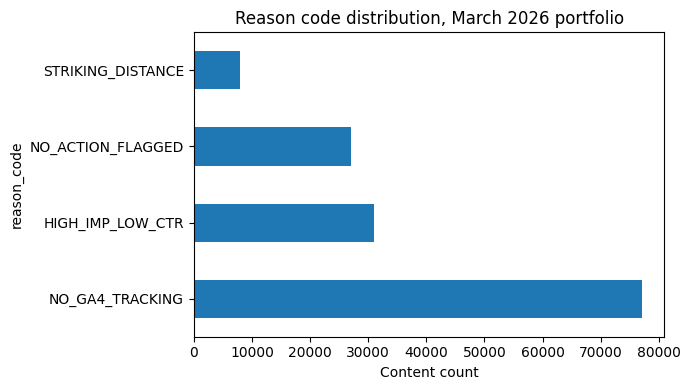

Figure written (COMMIT this file): ../figures/reason_code_distribution.png


In [5]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one -- typing sentences here breaks Run All.

import matplotlib.pyplot as plt

output_dir = "work/outputs" if os.path.exists("work/outputs") else "../outputs"
figures_dir = "work/figures" if os.path.exists("work/figures") else "../figures"
os.makedirs(output_dir, exist_ok=True)
os.makedirs(figures_dir, exist_ok=True)

# --- Queue CSV: NOT committed (regenerated every run) ---
queue_path = os.path.join(output_dir, "ranked_action_queue.csv")
action_queue[[
    "content_hash_id", "client_hash_id", "archetype", "reason_code", "action_label",
    "priority_score", "model_proba", "total_impressions", "avg_position",
    "position_tier", "imp_bucket", "has_ga4_data",
]].to_csv(queue_path, index=False)
print(f"Ranked queue written (out of git by design): {queue_path}  ({len(action_queue):,} rows)")

# --- Metrics JSON: committed, these are the paper's receipts ---
receipts = {
    "honest_holdout_metrics": honest_metrics,
    "monitoring_snapshot": monitoring_snapshot,
    "reason_code_counts": df["reason_code"].value_counts().to_dict(),
    "queue_size": int(len(action_queue)),
    "total_content_scored": int(len(df)),
}
metrics_path = os.path.join(output_dir, "w07_metrics.json")
with open(metrics_path, "w") as f:
    json.dump(receipts, f, indent=2, default=str)
print(f"Metrics receipts written (COMMIT this file): {metrics_path}")

# --- One reused figure: reason code distribution ---
fig, ax = plt.subplots(figsize=(7, 4))
df["reason_code"].value_counts().plot(kind="barh", ax=ax)
ax.set_xlabel("Content count")
ax.set_title("Reason code distribution, March 2026 portfolio")
plt.tight_layout()
fig_path = os.path.join(figures_dir, "reason_code_distribution.png")
plt.savefig(fig_path, dpi=150)
plt.show()
print(f"Figure written (COMMIT this file): {fig_path}")


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.